# 19. Neural Networks III: Training in Practice
@Shengli (Bruce) Jiang, University of South Carolina

## What We Covered in the Last Lecture

A neural network learns through a repeated cycle:

**forward pass -> loss -> backpropagation -> parameter update**

We also separated training, validation, and test data so that model selection does not use the final test set.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Explain epochs, batches, and parameter updates.
2. Explain how batch size changes training behavior.
3. Describe what the learning rate controls.
4. Distinguish backpropagation from an optimizer.
5. Compare basic SGD and Adam behavior.
6. Read training curves and recognize underfitting and overfitting.
7. Use early stopping, dropout, and L2 regularization.

## Running the Notebook

Run the cells from top to bottom.

TensorFlow will download MNIST the first time it is used. Some optimizer comparisons use a subset of MNIST so they run quickly during class.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import display
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(26)

## 1. What Happens Inside `model.fit()`?

For each mini-batch, Keras repeats the same learning loop derived in Lecture 18:

1. Select a batch.
2. Run the forward pass.
3. Calculate the batch loss.
4. Backpropagate the loss to calculate gradients.
5. Let the optimizer update the weights and biases.
6. Move to the next batch.

An **epoch** is complete after every training example has been used once.

**Important:** weights are updated once per batch, not once per epoch.

## 2. Epochs and Batches

Suppose we have 1,050 training examples and use `batch_size=100`.

The first 10 batches contain 100 examples each. The final batch contains 50 examples. Each batch still produces one parameter update.

In [2]:
n_samples = 1050
batch_size = 100

rows = []

for batch_number, start in enumerate(range(0, n_samples, batch_size), start=1):
    stop = min(start + batch_size, n_samples)
    rows.append({
        "Batch": batch_number,
        "First sample": start + 1,
        "Last sample": stop,
        "Samples": stop - start
    })

batch_table = pd.DataFrame(rows)
display(batch_table)

n_updates = len(batch_table)
print("Updates in one epoch:", n_updates)

,Batch,First sample,Last sample,Samples
0,1,1,100,100
1,2,101,200,100
2,3,201,300,100
3,4,301,400,100
4,5,401,500,100
5,6,501,600,100
6,7,601,700,100
7,8,701,800,100
8,9,801,900,100
9,10,901,1000,100


Updates in one epoch: 11


The number of updates in one epoch is

$$
N_{\mathrm{updates}}=
\left\lceil
\frac{N_{\mathrm{samples}}}{\mathrm{batch\ size}}
\right\rceil.
$$

For this example,

$$
\left\lceil\frac{1050}{100}\right\rceil=11.
$$

In [3]:
weight = 1.0
learning_rate = 0.1
batch_gradients = [2.0, 1.0, -0.5]

rows = []

for batch_number, gradient in enumerate(batch_gradients, start=1):
    weight_before = weight
    weight = weight - learning_rate * gradient

    rows.append({
        "Batch": batch_number,
        "Weight before": weight_before,
        "Batch gradient": gradient,
        "Weight after": weight
    })

display(pd.DataFrame(rows).round(3))

,Batch,Weight before,Batch gradient,Weight after
0,1,1.0,2.0,0.80
1,2,0.8,1.0,0.70
2,3,0.7,-0.5,0.75


Each batch starts from the latest parameter values. Learning therefore accumulates across batches.

Within one batch, all examples are evaluated using the same current parameters. Backpropagation then calculates the gradient of the average batch loss.

## 3. Why Use Mini-Batches?

Three common choices are:

| Batch choice | Main behavior |
|---|---|
| `batch_size=1` | many noisy updates |
| mini-batch | moderate noise and efficient computation |
| full batch | smooth gradient, but only one update per epoch |

Mini-batches are the standard compromise. Common starting values are 32, 64, 128, and 256.

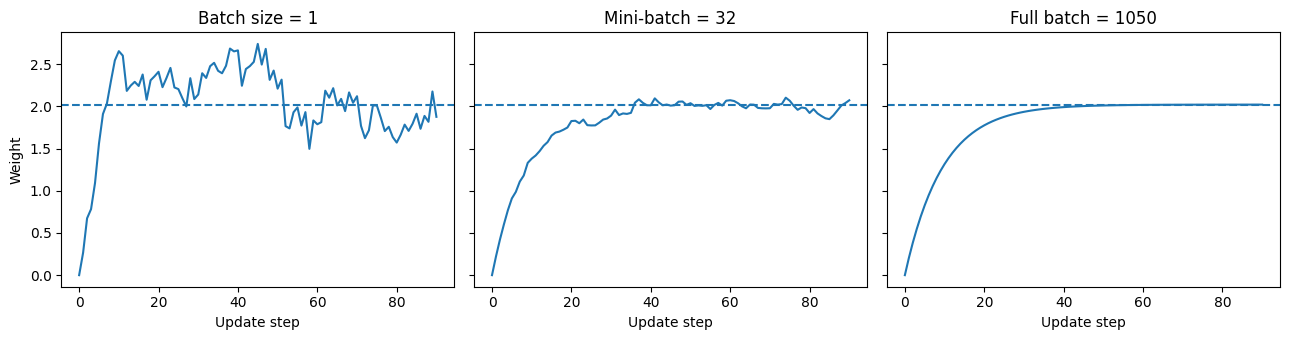

In [4]:
rng = np.random.default_rng(26)

sample_targets = rng.normal(loc=2.0, scale=2.0, size=1050)

def simulate_batch_updates(batch_size, n_steps=90, learning_rate=0.05):
    local_rng = np.random.default_rng(26)
    weight = 0.0
    path = [weight]

    for _ in range(n_steps):
        if batch_size == len(sample_targets):
            batch = sample_targets
        else:
            idx = local_rng.choice(
                len(sample_targets),
                size=batch_size,
                replace=False
            )
            batch = sample_targets[idx]

        gradient = 2.0 * (weight - batch.mean())
        weight = weight - learning_rate * gradient
        path.append(weight)

    return np.array(path)

path_1 = simulate_batch_updates(1)
path_32 = simulate_batch_updates(32)
path_full = simulate_batch_updates(1050)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)

for ax, path, title in zip(
    axes,
    [path_1, path_32, path_full],
    ["Batch size = 1", "Mini-batch = 32", "Full batch = 1050"]
):
    ax.plot(path)
    ax.axhline(sample_targets.mean(), linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Update step")

axes[0].set_ylabel("Weight")
plt.tight_layout()
plt.show()

The destination is similar, but the path changes.

- Small batches give noisier gradient estimates.
- Larger batches average over more examples and give smoother updates.
- A smoother update is not automatically a better model. Batch size also changes memory use, computation, and update frequency.

## 4. Learning Rate

The learning rate controls the size of each optimizer step.

For basic gradient descent,

$$
\theta_{t+1}
=
\theta_t-\eta\nabla_\theta L,
$$

where $\eta$ is the learning rate.

- Too small: learning is slow.
- Too large: updates can overshoot and the loss may oscillate or diverge.
- Reasonable values depend on the optimizer and problem.

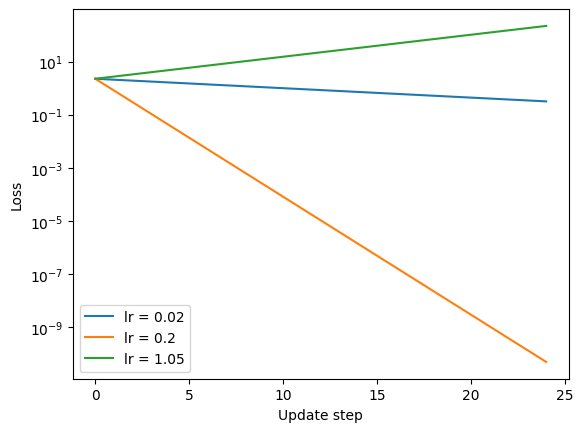

In [5]:
def run_quadratic_descent(learning_rate, n_steps=25):
    weight = 1.5
    losses = []

    for _ in range(n_steps):
        loss = weight ** 2
        gradient = 2.0 * weight

        losses.append(loss)
        weight = weight - learning_rate * gradient

    return np.array(losses)

learning_rates = [0.02, 0.20, 1.05]

for learning_rate in learning_rates:
    losses = run_quadratic_descent(learning_rate)
    plt.plot(losses, label=f"lr = {learning_rate}")

plt.xlabel("Update step")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.show()

This is a toy quadratic loss chosen to make the effect visible.

For neural networks, values such as `0.001`, `0.005`, and `0.01` are reasonable values to try, depending on the optimizer.

## 5. Backpropagation vs. Optimizer

These are different jobs.

**Backpropagation calculates the gradients**

$$
g_t=\nabla_\theta L.
$$

**The optimizer decides how to use those gradients**

$$
\theta_{t+1}=\theta_t+\Delta\theta_t.
$$

SGD uses the current mini-batch gradient directly. Adam also uses information accumulated from previous gradients.

Adam does **not** replace backpropagation.

In [6]:
sgd = keras.optimizers.SGD(learning_rate=0.01)
adam = keras.optimizers.Adam(learning_rate=0.001)

print("SGD learning rate:", float(sgd.learning_rate.numpy()))
print("Adam learning rate:", float(adam.learning_rate.numpy()))

SGD learning rate: 0.009999999776482582
Adam learning rate: 0.0010000000474974513


## 6. MNIST Setup for Training Practice

We now use MNIST to see these ideas in a real neural network.

For the optimizer comparison, we use one validation set because the goal is to study training behavior rather than perform a full hyperparameter search. The test set remains untouched until the end.

In [7]:
(x_all, y_all), (x_test, y_test) = keras.datasets.mnist.load_data()

x_all = x_all.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

rng = np.random.default_rng(26)
idx = rng.permutation(len(x_all))

x_all = x_all[idx]
y_all = y_all[idx]

x_train = x_all[:50000]
y_train = y_all[:50000]

x_val = x_all[50000:]
y_val = y_all[50000:]

print("Training:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Training: (50000, 28, 28) (50000,)
Validation: (10000, 28, 28) (10000,)
Test: (10000, 28, 28) (10000,)


In [8]:
def build_model(optimizer):
    model = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 7. SGD vs. Adam

The network architecture, batch size, and data stay the same. Only the optimizer changes.

We use a smaller training subset here so the comparison runs quickly.

In [9]:
x_train_demo = x_train[:20000]
y_train_demo = y_train[:20000]

x_val_demo = x_val[:5000]
y_val_demo = y_val[:5000]

tf.keras.utils.set_random_seed(26)
sgd_model = build_model(
    keras.optimizers.SGD(learning_rate=0.01)
)

sgd_history = sgd_model.fit(
    x_train_demo,
    y_train_demo,
    validation_data=(x_val_demo, y_val_demo),
    epochs=8,
    batch_size=128,
    verbose=0
)

tf.keras.utils.set_random_seed(26)
adam_model = build_model(
    keras.optimizers.Adam(learning_rate=0.001)
)

adam_history = adam_model.fit(
    x_train_demo,
    y_train_demo,
    validation_data=(x_val_demo, y_val_demo),
    epochs=8,
    batch_size=128,
    verbose=0
)

print("Finished SGD and Adam training.")

Finished SGD and Adam training.


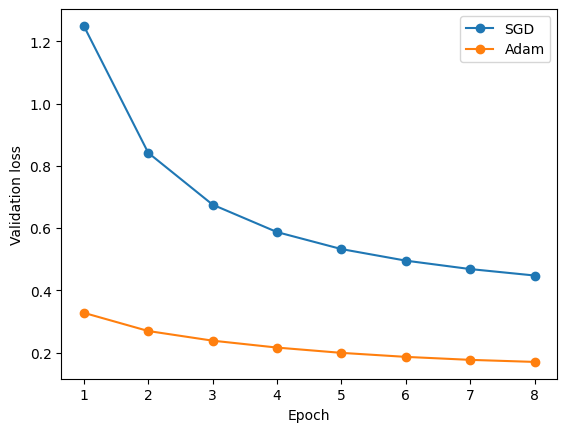

In [10]:
epochs = np.arange(1, 9)

plt.plot(
    epochs,
    sgd_history.history["val_loss"],
    marker="o",
    label="SGD"
)

plt.plot(
    epochs,
    adam_history.history["val_loss"],
    marker="o",
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.legend()
plt.show()

SGD follows the basic mini-batch gradient update. Adam adapts the update for each parameter using information from previous gradients.

Adam is often a convenient starting point, but optimizer performance still depends on the dataset, model, and learning rate.

## 8. Reading Training Curves

After each epoch, `model.fit()` can record:

- training loss
- validation loss
- training accuracy
- validation accuracy

Loss is especially useful for diagnosing whether training is still improving or beginning to overfit.

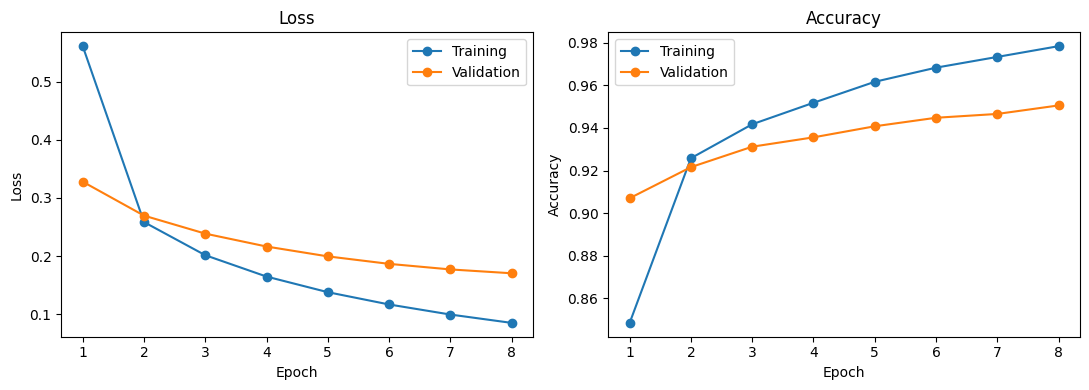

In [11]:
history = adam_history.history
epochs = np.arange(1, len(history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history["loss"], marker="o", label="Training")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, history["accuracy"], marker="o", label="Training")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Underfitting and Overfitting

### Underfitting

The model has not learned the training data well enough.

Typical signs:

- training loss is still high
- validation loss is also high
- training and validation curves are often close
- training accuracy itself is unsatisfactory

Possible causes include too little model capacity, too little training, a very small learning rate, or weak input features.

### Overfitting

Training performance keeps improving while validation performance stops improving.

Typical signs:

- training loss continues to decrease
- validation loss reaches a minimum and then increases
- the train-validation gap grows

The model is beginning to fit details that do not generalize.

A useful question when reading any training curve is:

> Is the model failing to fit the training data, or is it fitting the training data too specifically?

That separates underfitting from overfitting.

## 10. Regularization

Regularization limits how strongly a model can adapt to the training data.

Three common tools are:

1. **Early stopping**: stop when validation loss stops improving.
2. **Dropout**: randomly remove some hidden activations during training.
3. **L2 regularization**: penalize large weights.

Reducing the number of layers or neurons is another direct way to control model capacity.

In [12]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [13]:
dropout_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

In [14]:
l2_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(0.001)
    ),
    layers.Dense(10, activation="softmax")
])

## 11. Put the Regularization Tools Together

The example below uses L2 regularization, dropout, and early stopping in one model.

This is not a rule that all three must be used together. It simply shows where each tool enters the Keras workflow.

In [15]:
tf.keras.utils.set_random_seed(26)

regularized_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(0.001)
    ),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

regularized_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

regularized_history = regularized_model.fit(
    x_train_demo,
    y_train_demo,
    validation_data=(x_val_demo, y_val_demo),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=0
)

print("Epochs completed:", len(regularized_history.history["loss"]))

Epochs completed: 29


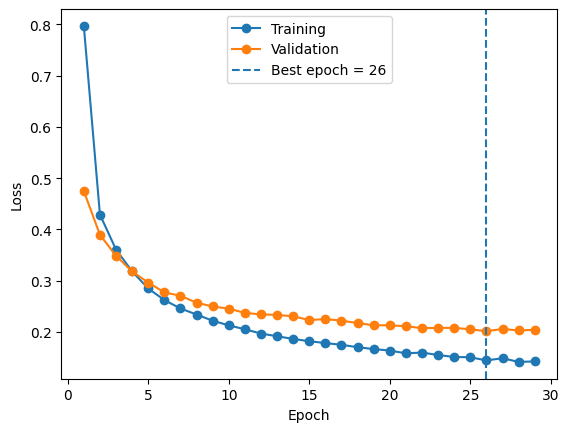

In [16]:
history = regularized_history.history
epochs = np.arange(1, len(history["loss"]) + 1)

plt.plot(epochs, history["loss"], marker="o", label="Training")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")

best_epoch = int(np.argmin(history["val_loss"]) + 1)
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Early stopping watches the validation loss. With `restore_best_weights=True`, the model returns to the weights from the best validation epoch instead of keeping the final epoch.

## 12. Final Test Evaluation

The test set is still untouched. Evaluate it only after the training decisions are finished.

In [17]:
test_loss, test_acc = regularized_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

Test loss: 0.1667
Test accuracy: 0.9686
